In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_excel('gare.xlsx')
df['Pos. divisione'] = df['Pos. divisione'].replace(0, np.nan)
df = df[df['Risultato'].notnull()].copy()
df['Data'] = pd.to_datetime(df['Data'])
gare = df[(~df['Amichevole']) & (df['Disciplina'] != 'Steel')]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 0 to 25
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Data                 26 non-null     datetime64[ns]
 1   Evento               26 non-null     object        
 2   Disciplina           26 non-null     object        
 3   Amichevole           26 non-null     bool          
 4   Livello              26 non-null     int64         
 5   Poligono             25 non-null     object        
 6   Divisione            26 non-null     object        
 7   Classe               26 non-null     object        
 8   Mire                 26 non-null     object        
 9   Arma                 26 non-null     object        
 10  Tempo/Punti          26 non-null     float64       
 11  Primo tempo/punti    26 non-null     float64       
 12  Primo tempo/punti A  8 non-null      float64       
 13  Risultato            26 non-null     float

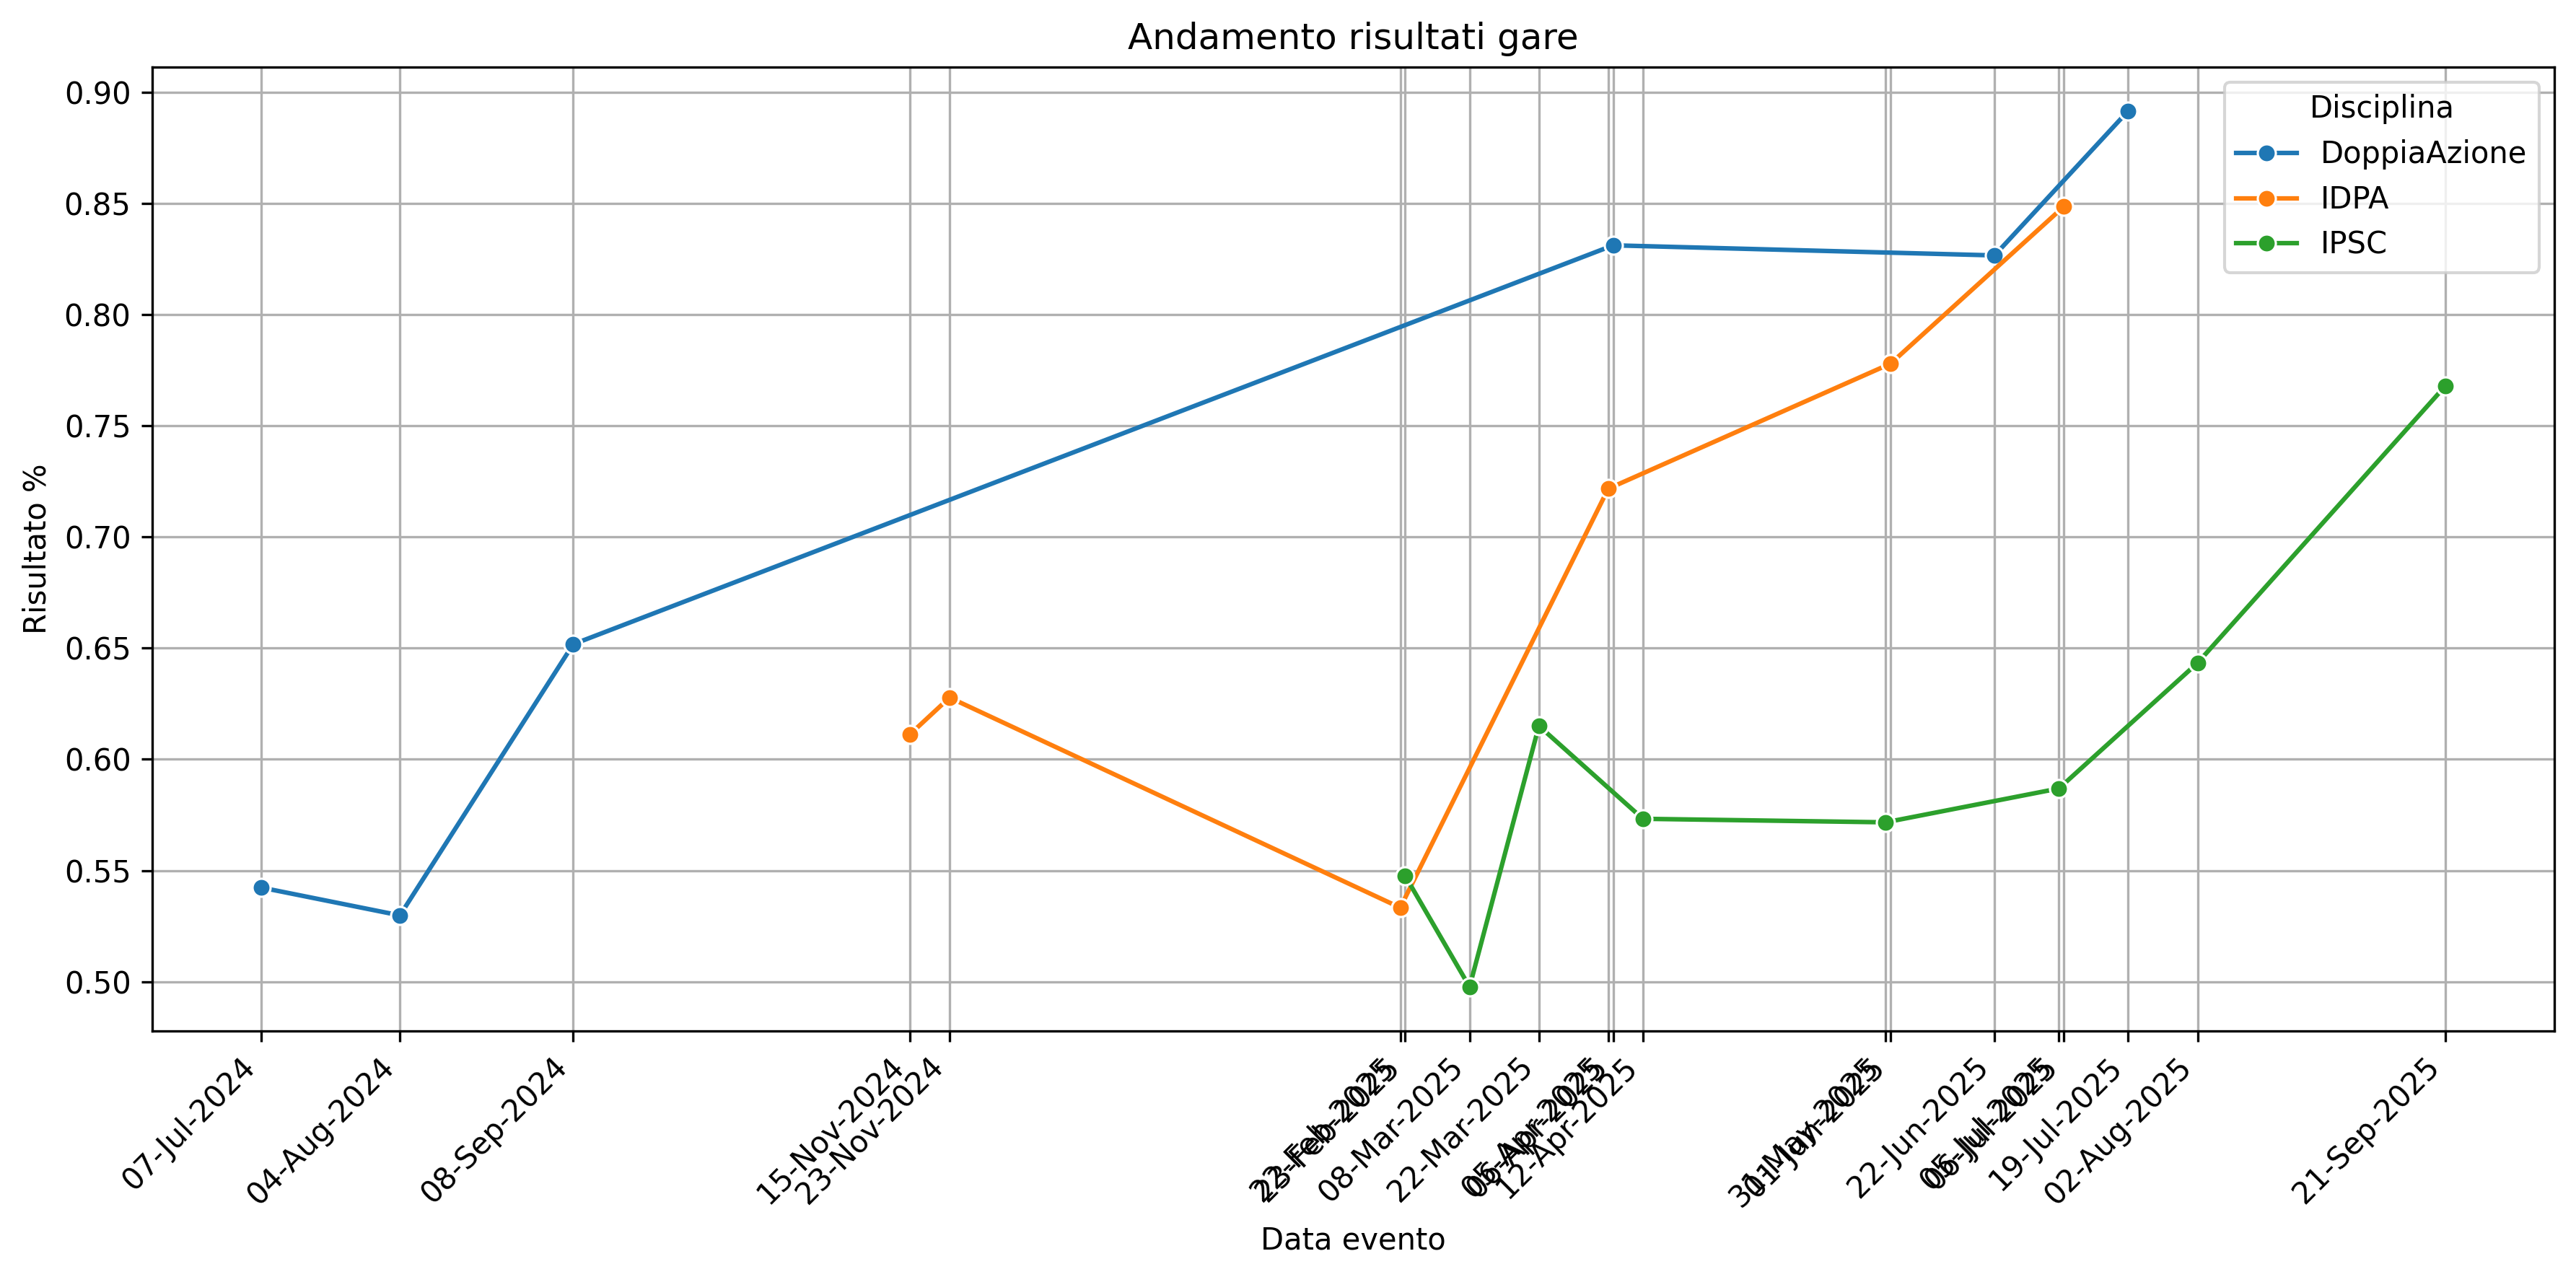

In [2]:

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Lineplot with markers
sns.lineplot(
    data=gare,
    x='Data',
    y='Risultato',
    hue='Disciplina',
    ax=ax,
    legend='full',
    marker='o'  # Add markers to the line
)

# Set event-based x-axis formatting (optional: rotate for better readability)
ax.set_xticks(gare['Data'].unique())  # Set ticks at each unique event date
ax.set_xticklabels(gare['Data'].dt.strftime('%d-%b-%Y'), rotation=45, ha='right')

# Add grid, title, and show
plt.grid(True)
plt.title('Andamento risultati gare')
plt.xlabel('Data evento')
plt.ylabel('Risultato %')
plt.tight_layout()
plt.show()

In [3]:
ipsc = gare[gare['Disciplina'] == 'IPSC'].copy().reset_index(drop=True)

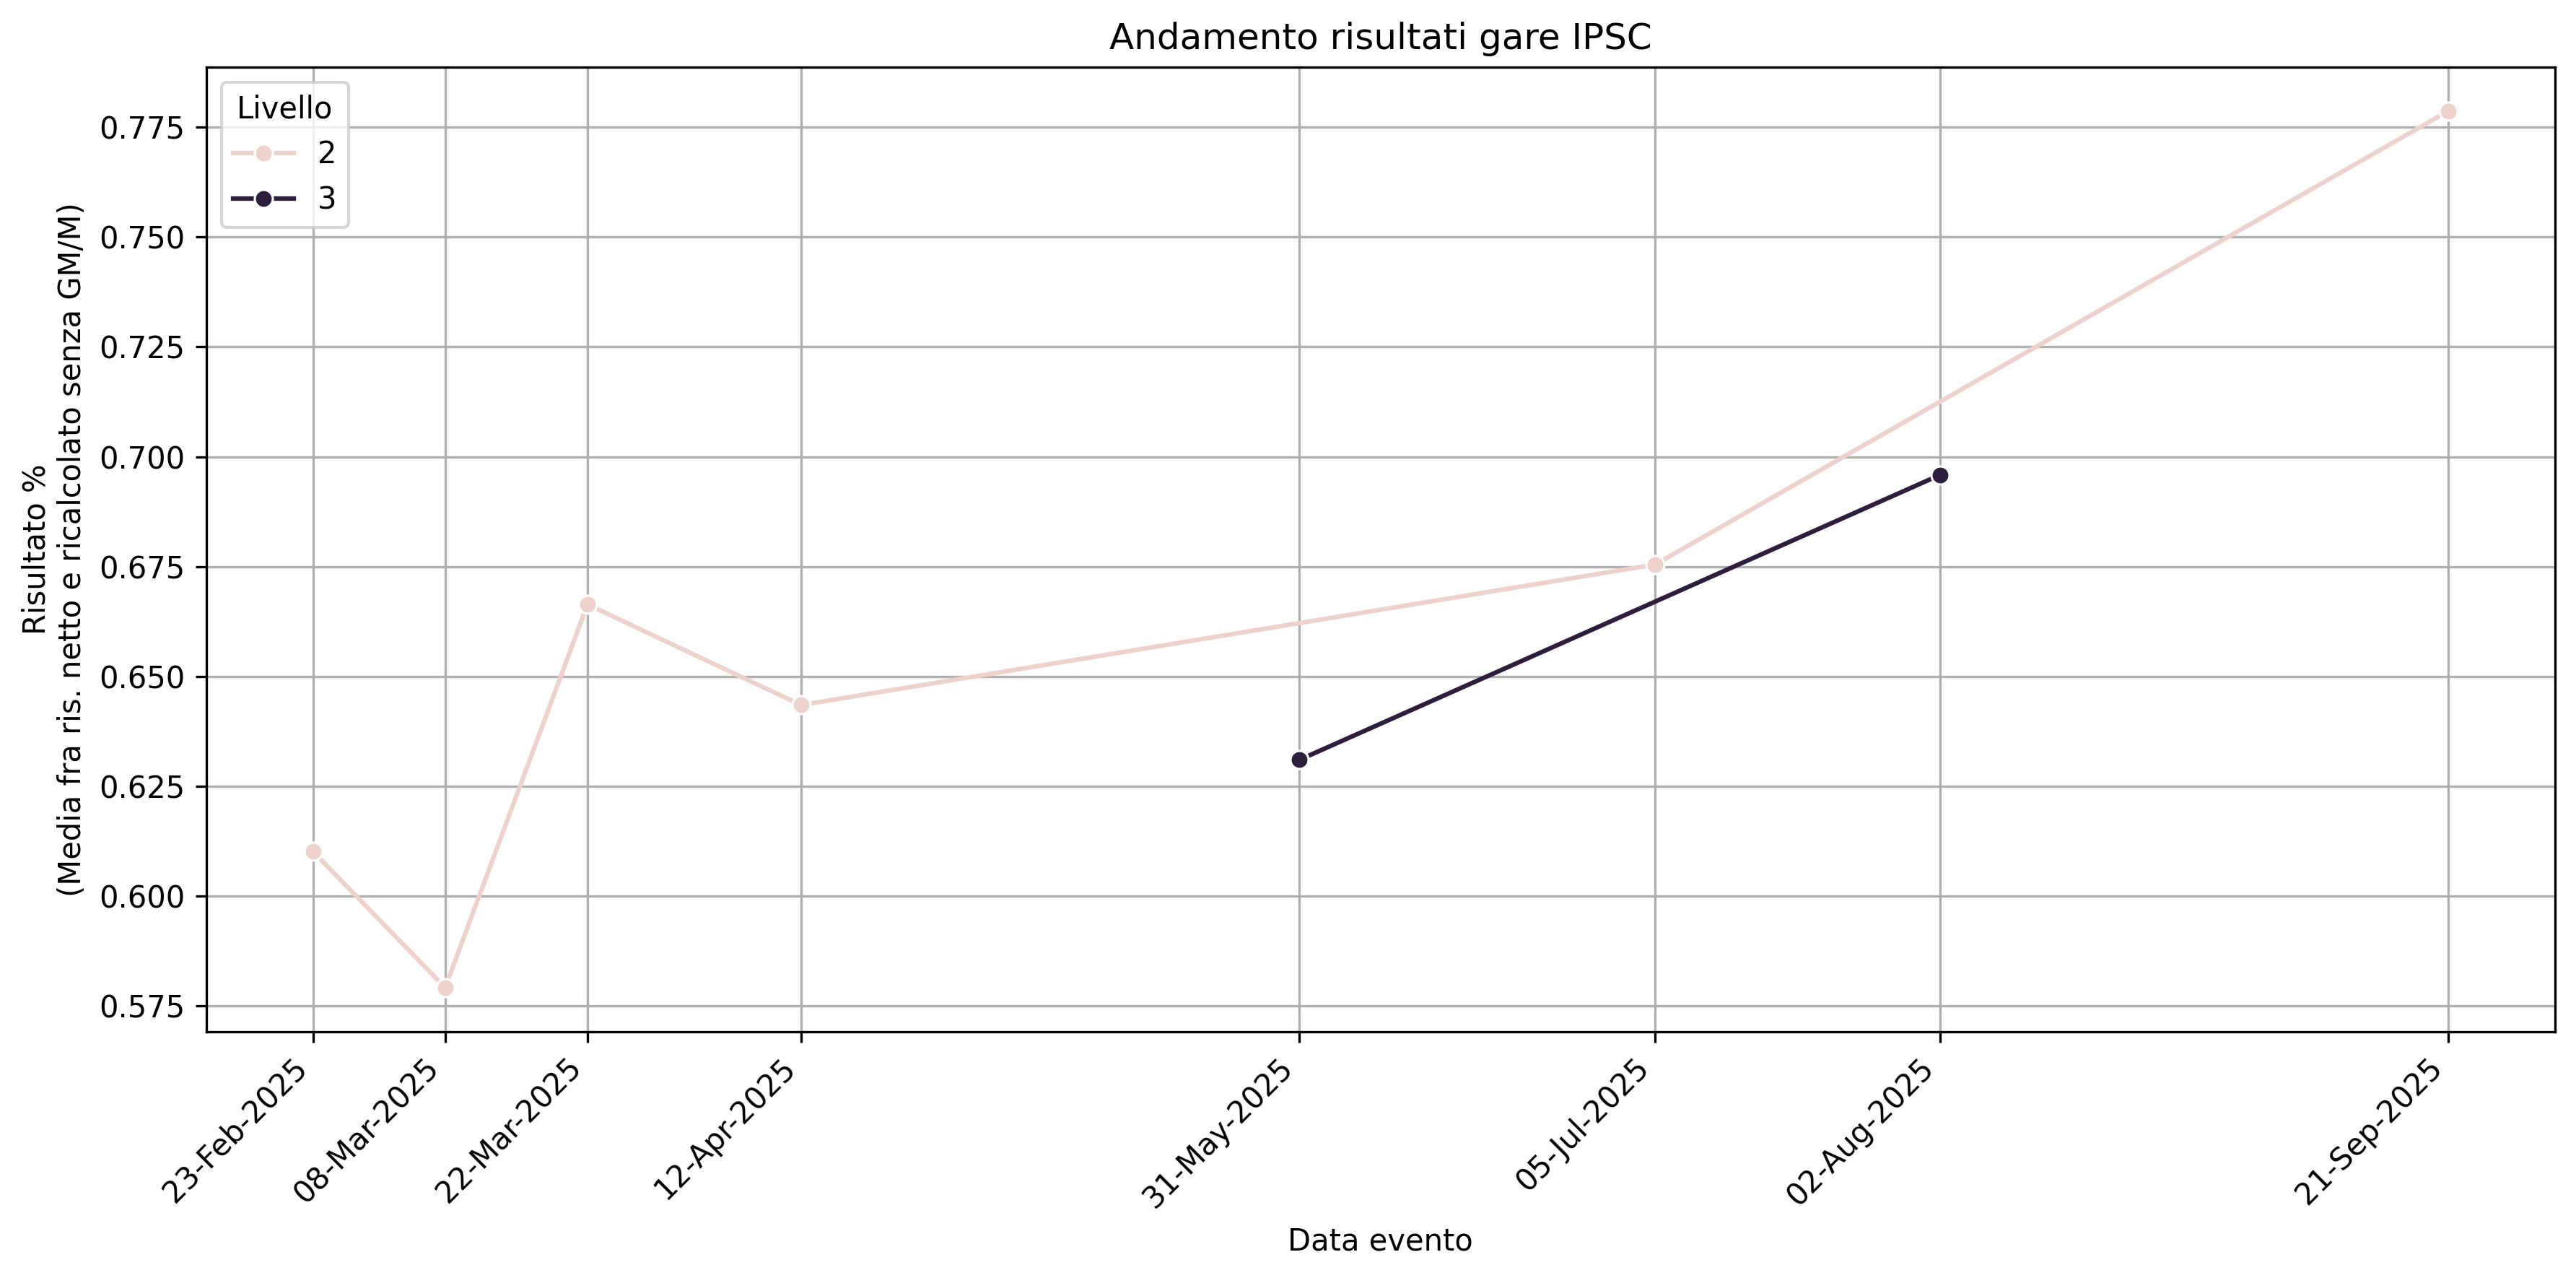

In [4]:

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Lineplot with markers
sns.lineplot(
    data=ipsc,
    x='Data',
    y='Ris. IPSC',
    hue='Livello',
    ax=ax,
    legend='full',
    marker='o'  # Add markers to the line
)

# Set event-based x-axis formatting (optional: rotate for better readability)
ax.set_xticks(ipsc['Data'].unique())  # Set ticks at each unique event date
ax.set_xticklabels(ipsc['Data'].dt.strftime('%d-%b-%Y'), rotation=45, ha='right')

# Add grid, title, and show
plt.grid(True)
plt.xlabel('Data evento')
plt.ylabel('Risultato %\n(Media fra ris. netto e ricalcolato senza GM/M)')
plt.title('Andamento risultati gare IPSC')
plt.tight_layout()
plt.show()

In [5]:
ipsc[
    (ipsc['Data'].dt.year == 2025) & (ipsc['Evento'].str.contains('MA')) | (ipsc['Livello'] == 3)
    ]['Ris. IPSC ABCD'].mean() - 0.16

0.5533035666401611